# 06 — Model Selection & Comparison

**Objective**: Compare gradient boosting frameworks (LightGBM, XGBoost, CatBoost) on the credit risk dataset, track experiments with MLFlow, and explain predictions using SHAP.

## Models

| Model | Why |
|-------|-----|
| **LightGBM** | Fast, histogram-based, handles NaN natively, leaf-wise growth |
| **XGBoost** | Mature, robust regularisation, level-wise growth |
| **CatBoost** | Native categorical support, ordered boosting, symmetric trees |

## Metrics

With ~8% default rate (1:11 imbalance), we focus on:
- **AUC-ROC** — discrimination ability across all thresholds
- **PR-AUC** — precision-recall trade-off (sensitive to class imbalance)
- **F1 Score** — harmonic mean of precision and recall
- **Log Loss** — probabilistic calibration quality

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import time

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    log_loss,
    roc_curve,
    precision_recall_curve,
)

import mlflow
import mlflow.lightgbm
import mlflow.xgboost
import mlflow.catboost

import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Project paths
PROJECT_ROOT = Path("..").resolve()
FEATURES_DIR = PROJECT_ROOT / "data" / "features"  # Gold layer
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# MLFlow setup
mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT}/mlruns/mlflow.db")
mlflow.set_experiment("credit-risk-default-prediction")

RANDOM_STATE = 42

print(f"Project root:  {PROJECT_ROOT}")
print(f"Features dir:  {FEATURES_DIR}")
print(f"Figures dir:   {FIGURES_DIR}")
print(f"MLFlow URI:    sqlite:///{PROJECT_ROOT}/mlruns/mlflow.db")

/home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root:  /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform
Features dir:  /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/data/features
Figures dir:   /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/reports/figures
MLFlow URI:    sqlite:////home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/mlruns/mlflow.db


## 2. Data Preparation

In [2]:
# Load gold layer features
df = pd.read_parquet(FEATURES_DIR / "train_features.parquet")

print(f"Gold layer shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nTarget distribution:")
print(df["TARGET"].value_counts())
print(f"\nDefault rate: {df['TARGET'].mean()*100:.2f}%")
print(f"Imbalance ratio: 1:{int((1-df['TARGET'].mean())/df['TARGET'].mean())} (non-default : default)")

Gold layer shape: 307,511 rows x 389 columns

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%
Imbalance ratio: 1:11 (non-default : default)


In [3]:
# Separate target and features
y = df["TARGET"]
X = df.drop(columns=["SK_ID_CURR", "TARGET"])

# Identify column types
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"  Numeric features:     {len(numeric_cols):>4}")
print(f"  Categorical features: {len(categorical_cols):>4}")
print(f"\nMissing values: {X.isnull().any().sum()} / {X.shape[1]} columns have NaNs")
print(f"Overall NaN rate: {X.isnull().sum().sum() / (X.shape[0] * X.shape[1]) * 100:.2f}%")

Feature matrix: 307,511 rows x 387 columns
  Numeric features:      371
  Categorical features:   16

Missing values: 173 / 387 columns have NaNs
Overall NaN rate: 13.95%


In [4]:
# Stratified train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train set: {X_train.shape[0]:>8,} rows  (default rate: {y_train.mean()*100:.2f}%)")
print(f"Val set:   {X_val.shape[0]:>8,} rows  (default rate: {y_val.mean()*100:.2f}%)")
print(f"\nStratification preserved: train={y_train.mean()*100:.2f}%, val={y_val.mean()*100:.2f}%")

Train set:  246,008 rows  (default rate: 8.07%)
Val set:     61,503 rows  (default rate: 8.07%)

Stratification preserved: train=8.07%, val=8.07%


In [5]:
# --- Preprocessing for LightGBM / XGBoost ---
# Both handle NaN natively for numeric features, so only encode categoricals.

cat_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train_lgbx = X_train.copy()
X_val_lgbx = X_val.copy()

if categorical_cols:
    X_train_lgbx[categorical_cols] = cat_encoder.fit_transform(X_train[categorical_cols].astype(str))
    X_val_lgbx[categorical_cols] = cat_encoder.transform(X_val[categorical_cols].astype(str))

# --- Preprocessing for CatBoost ---
# CatBoost handles categoricals natively — just identify their indices.

X_train_cb = X_train.copy()
X_val_cb = X_val.copy()

if categorical_cols:
    for col in categorical_cols:
        X_train_cb[col] = X_train_cb[col].astype(str).fillna("nan")
        X_val_cb[col] = X_val_cb[col].astype(str).fillna("nan")

cat_feature_indices = [X_train_cb.columns.get_loc(c) for c in categorical_cols]

print(f"LightGBM/XGBoost: OrdinalEncoder on {len(categorical_cols)} categorical cols, NaN kept for {len(numeric_cols)} numeric cols")
print(f"CatBoost:         {len(categorical_cols)} native categorical features (indices: {cat_feature_indices[:5]}{'...' if len(cat_feature_indices) > 5 else ''})")

LightGBM/XGBoost: OrdinalEncoder on 16 categorical cols, NaN kept for 371 numeric cols
CatBoost:         16 native categorical features (indices: [0, 1, 2, 3, 9]...)


In [6]:
# Helper to compute all metrics
def compute_metrics(y_true, y_proba, y_pred):
    return {
        "auc_roc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "f1": f1_score(y_true, y_pred),
        "log_loss": log_loss(y_true, y_proba),
    }

# Store results for comparison
results = {}
models = {}
curves = {}  # fpr/tpr and precision/recall for each model
training_times = {}

print("Helper functions ready.")

Helper functions ready.


## 3. LightGBM

In [7]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=11,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    device="gpu",
)

print("Training LightGBM (GPU)...")
start = time.time()
lgb_model.fit(
    X_train_lgbx, y_train,
    eval_set=[(X_val_lgbx, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0),
    ],
)
lgb_time = time.time() - start
training_times["LightGBM"] = lgb_time

print(f"Done in {lgb_time:.1f}s  (best iteration: {lgb_model.best_iteration_})")

# Predict
lgb_proba = lgb_model.predict_proba(X_val_lgbx)[:, 1]
lgb_pred = (lgb_proba >= 0.5).astype(int)

# Metrics
lgb_metrics = compute_metrics(y_val, lgb_proba, lgb_pred)
results["LightGBM"] = lgb_metrics
models["LightGBM"] = lgb_model

fpr_lgb, tpr_lgb, _ = roc_curve(y_val, lgb_proba)
prec_lgb, rec_lgb, _ = precision_recall_curve(y_val, lgb_proba)
curves["LightGBM"] = {"fpr": fpr_lgb, "tpr": tpr_lgb, "precision": prec_lgb, "recall": rec_lgb}

print(f"\nLightGBM — Validation Metrics:")
print(f"  {'AUC-ROC:':<15s} {lgb_metrics['auc_roc']:.4f}")
print(f"  {'PR-AUC:':<15s} {lgb_metrics['pr_auc']:.4f}")
print(f"  {'F1 Score:':<15s} {lgb_metrics['f1']:.4f}")
print(f"  {'Log Loss:':<15s} {lgb_metrics['log_loss']:.4f}")

Training LightGBM (GPU)...
Done in 99.4s  (best iteration: 1)

LightGBM — Validation Metrics:
  AUC-ROC:        0.7140
  PR-AUC:         0.1812
  F1 Score:       0.0000
  Log Loss:       0.2763


In [8]:
# Log LightGBM to MLFlow
with mlflow.start_run(run_name="lightgbm_v1"):
    mlflow.log_param("model_type", "LightGBM")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("num_leaves", 31)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("scale_pos_weight", 11)
    mlflow.log_param("early_stopping_rounds", 50)
    mlflow.log_param("best_iteration", lgb_model.best_iteration_)
    mlflow.log_param("n_features", X_train_lgbx.shape[1])
    mlflow.log_param("train_size", X_train.shape[0])
    mlflow.log_param("val_size", X_val.shape[0])
    mlflow.log_param("random_state", RANDOM_STATE)

    for metric_name, metric_value in lgb_metrics.items():
        mlflow.log_metric(metric_name, metric_value)
    mlflow.log_metric("training_time_s", lgb_time)

    mlflow.lightgbm.log_model(lgb_model, "model")

    lgb_run_id = mlflow.active_run().info.run_id
    print(f"MLFlow run logged: {lgb_run_id}")

2026/03/24 22:04:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/24 22:04:31 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLFlow run logged: 22e78a32d1794256a6a989b62990c959


## 4. XGBoost

In [9]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=11,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="auc",
    verbosity=0,
    device="cuda",
    tree_method="hist",
    early_stopping_rounds=150
)

print("Training XGBoost (GPU)...")
start = time.time()
xgb_model.fit(
    X_train_lgbx, y_train,
    eval_set=[(X_val_lgbx, y_val)],
    verbose=False,
)
xgb_time = time.time() - start
training_times["XGBoost"] = xgb_time

print(f"Done in {xgb_time:.1f}s  (best iteration: {xgb_model.best_iteration})")

# Predict
xgb_proba = xgb_model.predict_proba(X_val_lgbx)[:, 1]
xgb_pred = (xgb_proba >= 0.5).astype(int)

# Metrics
xgb_metrics = compute_metrics(y_val, xgb_proba, xgb_pred)
results["XGBoost"] = xgb_metrics
models["XGBoost"] = xgb_model

fpr_xgb, tpr_xgb, _ = roc_curve(y_val, xgb_proba)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_val, xgb_proba)
curves["XGBoost"] = {"fpr": fpr_xgb, "tpr": tpr_xgb, "precision": prec_xgb, "recall": rec_xgb}

print(f"\nXGBoost — Validation Metrics:")
print(f"  {'AUC-ROC:':<15s} {xgb_metrics['auc_roc']:.4f}")
print(f"  {'PR-AUC:':<15s} {xgb_metrics['pr_auc']:.4f}")
print(f"  {'F1 Score:':<15s} {xgb_metrics['f1']:.4f}")
print(f"  {'Log Loss:':<15s} {xgb_metrics['log_loss']:.4f}")

Training XGBoost (GPU)...
Done in 15.7s  (best iteration: 344)

XGBoost — Validation Metrics:
  AUC-ROC:        0.7825
  PR-AUC:         0.2801
  F1 Score:       0.3045
  Log Loss:       0.4915


In [10]:
# Log XGBoost to MLFlow
with mlflow.start_run(run_name="xgboost_v1"):
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("scale_pos_weight", 11)
    mlflow.log_param("early_stopping_rounds", 50)
    mlflow.log_param("best_iteration", xgb_model.best_iteration)
    mlflow.log_param("n_features", X_train_lgbx.shape[1])
    mlflow.log_param("train_size", X_train.shape[0])
    mlflow.log_param("val_size", X_val.shape[0])
    mlflow.log_param("random_state", RANDOM_STATE)

    for metric_name, metric_value in xgb_metrics.items():
        mlflow.log_metric(metric_name, metric_value)
    mlflow.log_metric("training_time_s", xgb_time)

    mlflow.xgboost.log_model(xgb_model, "model")

    xgb_run_id = mlflow.active_run().info.run_id
    print(f"MLFlow run logged: {xgb_run_id}")

2026/03/24 22:04:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLFlow run logged: d54bb2506a5440a89d758f355eb0bf60


## 5. CatBoost

In [11]:
cb_model = cb.CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    auto_class_weights="Balanced",
    random_seed=RANDOM_STATE,
    verbose=100,
    task_type="GPU",
)

print("Training CatBoost (GPU)...")
start = time.time()
cb_model.fit(
    X_train_cb, y_train,
    eval_set=(X_val_cb, y_val),
    cat_features=cat_feature_indices,
    early_stopping_rounds=50,
)
cb_time = time.time() - start
training_times["CatBoost"] = cb_time

print(f"\nDone in {cb_time:.1f}s  (best iteration: {cb_model.get_best_iteration()})")

# Predict
cb_proba = cb_model.predict_proba(X_val_cb)[:, 1]
cb_pred = (cb_proba >= 0.5).astype(int)

# Metrics
cb_metrics = compute_metrics(y_val, cb_proba, cb_pred)
results["CatBoost"] = cb_metrics
models["CatBoost"] = cb_model

fpr_cb, tpr_cb, _ = roc_curve(y_val, cb_proba)
prec_cb, rec_cb, _ = precision_recall_curve(y_val, cb_proba)
curves["CatBoost"] = {"fpr": fpr_cb, "tpr": tpr_cb, "precision": prec_cb, "recall": rec_cb}

print(f"\nCatBoost — Validation Metrics:")
print(f"  {'AUC-ROC:':<15s} {cb_metrics['auc_roc']:.4f}")
print(f"  {'PR-AUC:':<15s} {cb_metrics['pr_auc']:.4f}")
print(f"  {'F1 Score:':<15s} {cb_metrics['f1']:.4f}")
print(f"  {'Log Loss:':<15s} {cb_metrics['log_loss']:.4f}")

Training CatBoost (GPU)...
0:	learn: 0.6861255	test: 0.6862135	best: 0.6862135 (0)	total: 168ms	remaining: 1m 23s
100:	learn: 0.5764364	test: 0.5813093	best: 0.5813093 (100)	total: 12.6s	remaining: 49.7s
200:	learn: 0.5609161	test: 0.5712606	best: 0.5712606 (200)	total: 23.4s	remaining: 34.8s
300:	learn: 0.5501806	test: 0.5672467	best: 0.5672467 (300)	total: 33.9s	remaining: 22.4s
400:	learn: 0.5411475	test: 0.5644628	best: 0.5644628 (400)	total: 44.1s	remaining: 10.9s
499:	learn: 0.5335744	test: 0.5628277	best: 0.5628277 (499)	total: 54s	remaining: 0us
bestTest = 0.5628277001
bestIteration = 499

Done in 59.8s  (best iteration: 499)

CatBoost — Validation Metrics:
  AUC-ROC:        0.7825
  PR-AUC:         0.2794
  F1 Score:       0.2935
  Log Loss:       0.5431


In [12]:
# Log CatBoost to MLFlow
with mlflow.start_run(run_name="catboost_v1"):
    mlflow.log_param("model_type", "CatBoost")
    mlflow.log_param("iterations", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("depth", 6)
    mlflow.log_param("auto_class_weights", "Balanced")
    mlflow.log_param("early_stopping_rounds", 50)
    mlflow.log_param("best_iteration", cb_model.get_best_iteration())
    mlflow.log_param("n_features", X_train_cb.shape[1])
    mlflow.log_param("n_cat_features", len(categorical_cols))
    mlflow.log_param("train_size", X_train.shape[0])
    mlflow.log_param("val_size", X_val.shape[0])
    mlflow.log_param("random_state", RANDOM_STATE)

    for metric_name, metric_value in cb_metrics.items():
        mlflow.log_metric(metric_name, metric_value)
    mlflow.log_metric("training_time_s", cb_time)

    mlflow.catboost.log_model(cb_model, "model")

    cb_run_id = mlflow.active_run().info.run_id
    print(f"MLFlow run logged: {cb_run_id}")

2026/03/24 22:06:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLFlow run logged: a7f9873cf5ab4a67b8af6988d7fded79


## 6. Model Comparison

In [13]:
# Side-by-side comparison table
comparison = pd.DataFrame(results).T
comparison.columns = ["AUC-ROC", "PR-AUC", "F1 Score", "Log Loss"]

print("Model Comparison")
print("=" * 70)
print(comparison.to_string(float_format="{:.4f}".format))
print("=" * 70)

# Best per metric (higher is better for AUC-ROC, PR-AUC, F1; lower is better for Log Loss)
print("\nBest model per metric:")
for col in comparison.columns:
    if col == "Log Loss":
        best = comparison[col].idxmin()
    else:
        best = comparison[col].idxmax()
    print(f"  {col:<15s} {best} ({comparison.loc[best, col]:.4f})")

Model Comparison
          AUC-ROC  PR-AUC  F1 Score  Log Loss
LightGBM   0.7140  0.1812    0.0000    0.2763
XGBoost    0.7825  0.2801    0.3045    0.4915
CatBoost   0.7825  0.2794    0.2935    0.5431

Best model per metric:
  AUC-ROC         XGBoost (0.7825)
  PR-AUC          XGBoost (0.2801)
  F1 Score        XGBoost (0.3045)
  Log Loss        LightGBM (0.2763)


Figure saved: /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/reports/figures/06_roc_pr_comparison.png


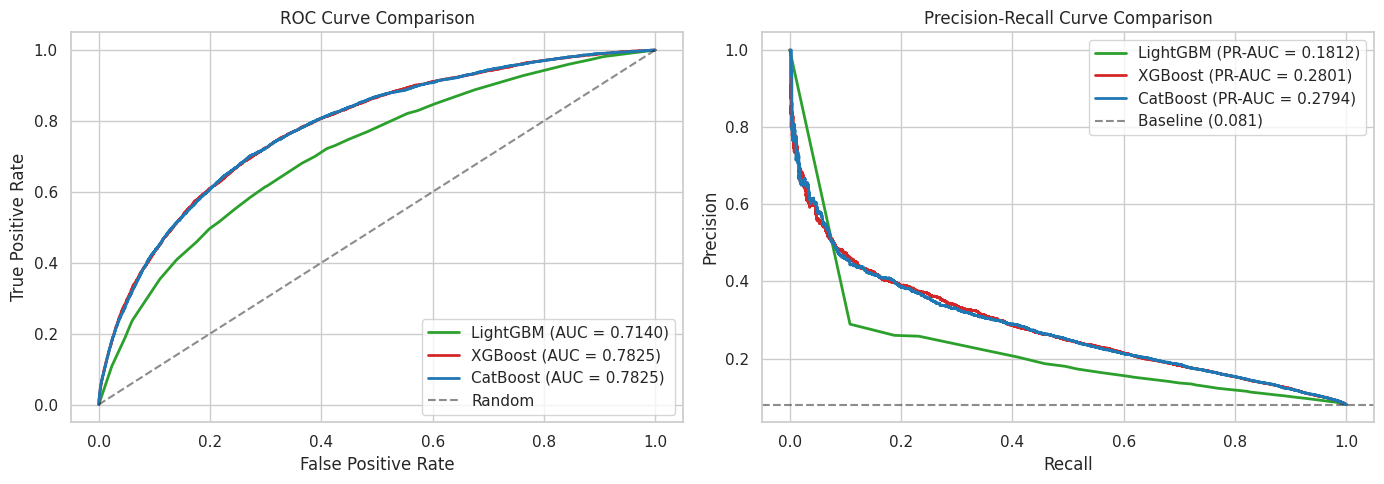

In [14]:
# Overlay ROC curves
colors = {"LightGBM": "#2ca02c", "XGBoost": "#d62728", "CatBoost": "#1f77b4"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in results:
    axes[0].plot(
        curves[name]["fpr"], curves[name]["tpr"],
        label=f"{name} (AUC = {results[name]['auc_roc']:.4f})",
        color=colors[name], lw=2,
    )
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve Comparison")
axes[0].legend(loc="lower right")

# Overlay PR curves
for name in results:
    axes[1].plot(
        curves[name]["recall"], curves[name]["precision"],
        label=f"{name} (PR-AUC = {results[name]['pr_auc']:.4f})",
        color=colors[name], lw=2,
    )
axes[1].axhline(y=y_val.mean(), color="k", linestyle="--", alpha=0.5, label=f"Baseline ({y_val.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve Comparison")
axes[1].legend(loc="upper right")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "06_roc_pr_comparison.png", dpi=150, bbox_inches="tight")
print(f"Figure saved: {FIGURES_DIR / '06_roc_pr_comparison.png'}")
plt.show()

Figure saved: /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/reports/figures/06_training_time.png


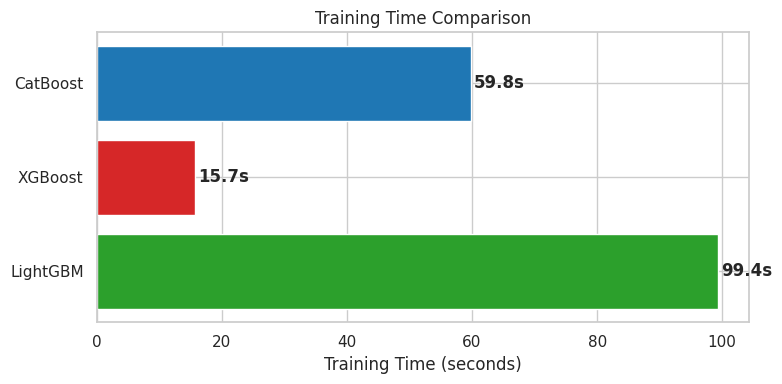

In [15]:
# Training time comparison
fig, ax = plt.subplots(figsize=(8, 4))

names = list(training_times.keys())
times = list(training_times.values())
bar_colors = [colors[n] for n in names]

bars = ax.barh(names, times, color=bar_colors, edgecolor="white")
for bar, t in zip(bars, times):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{t:.1f}s", va="center", fontweight="bold")

ax.set_xlabel("Training Time (seconds)")
ax.set_title("Training Time Comparison")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "06_training_time.png", dpi=150, bbox_inches="tight")
print(f"Figure saved: {FIGURES_DIR / '06_training_time.png'}")
plt.show()

## 7. SHAP Analysis

In [16]:
# Select the best model by AUC-ROC
best_model_name = comparison["AUC-ROC"].idxmax()
print(f"Best model by AUC-ROC: {best_model_name} ({comparison.loc[best_model_name, 'AUC-ROC']:.4f})")

best_model = models[best_model_name]

# Choose the right validation set for SHAP
if best_model_name == "CatBoost":
    X_shap = X_val_cb
else:
    X_shap = X_val_lgbx

# Use a sample for SHAP (speed)
shap_sample_size = 5000
np.random.seed(RANDOM_STATE)
shap_idx = np.random.choice(X_shap.shape[0], size=shap_sample_size, replace=False)
X_shap_sample = X_shap.iloc[shap_idx]

print(f"Computing SHAP values on {shap_sample_size:,} samples...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap_sample)

# For binary classifiers, shap_values may be a list [class_0, class_1]
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # positive class

print(f"SHAP values shape: {shap_values.shape}")

Best model by AUC-ROC: XGBoost (0.7825)
Computing SHAP values on 5,000 samples...
SHAP values shape: (5000, 387)


Figure saved: /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/reports/figures/06_shap_beeswarm.png


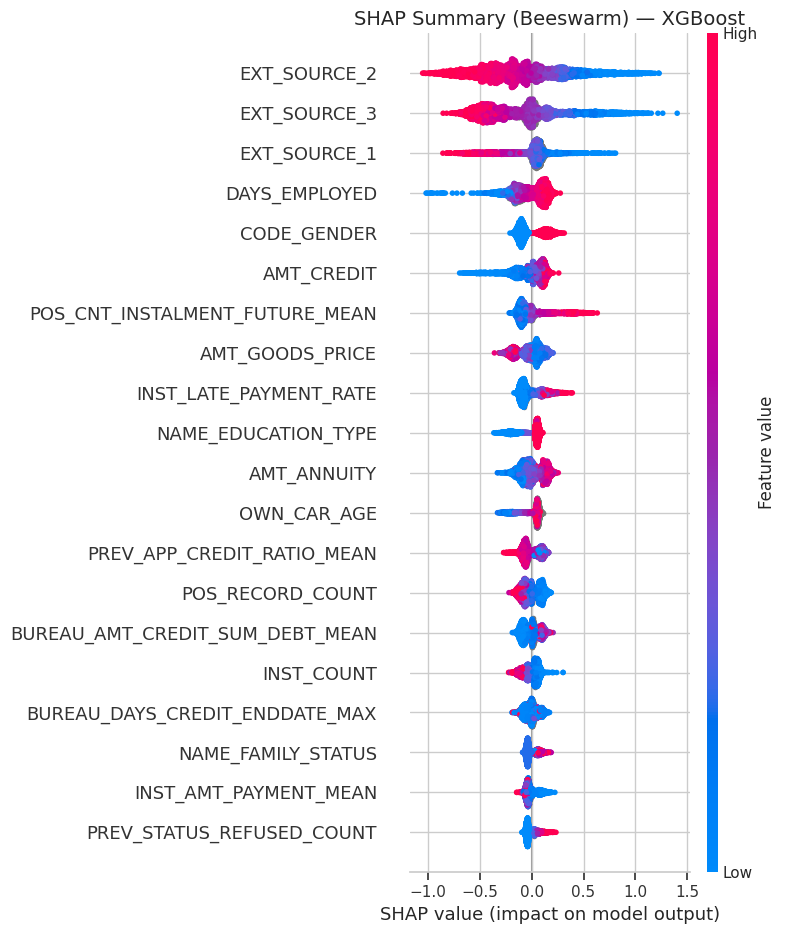

In [17]:
# SHAP beeswarm plot — top 20 features
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap_sample,
    max_display=20,
    show=False,
)
plt.title(f"SHAP Summary (Beeswarm) — {best_model_name}", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_shap_beeswarm.png", dpi=150, bbox_inches="tight")
print(f"Figure saved: {FIGURES_DIR / '06_shap_beeswarm.png'}")
plt.show()

Figure saved: /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/reports/figures/06_shap_bar.png


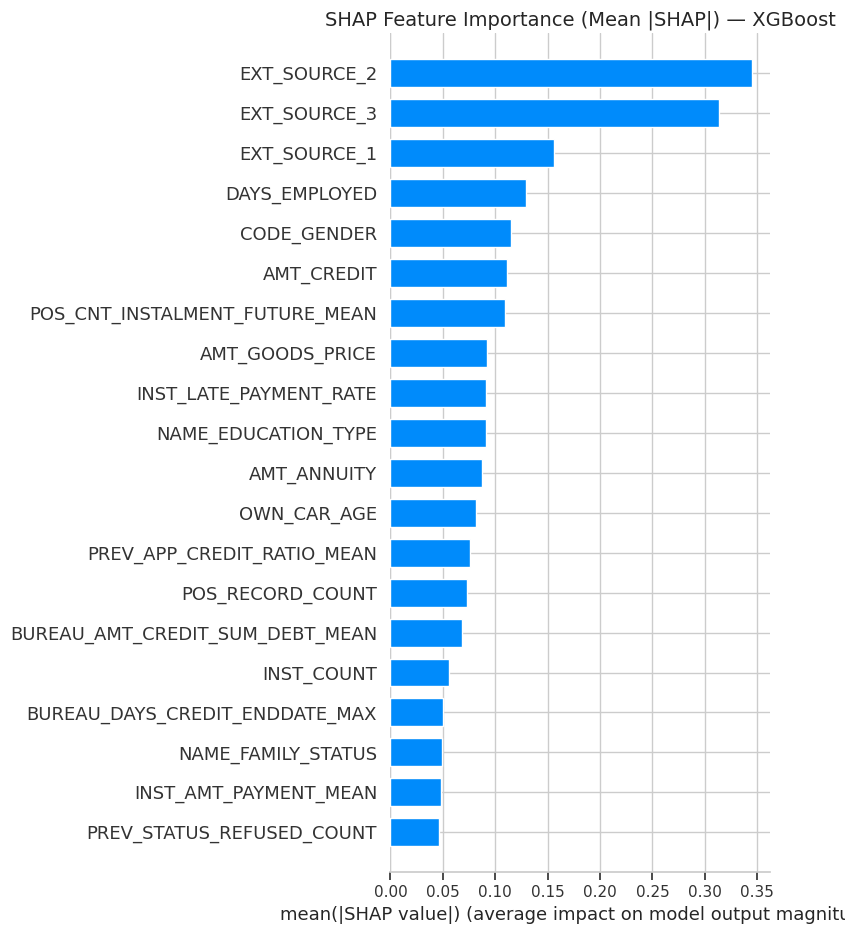

In [18]:
# SHAP bar plot — mean absolute SHAP value per feature
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap_sample,
    plot_type="bar",
    max_display=20,
    show=False,
)
plt.title(f"SHAP Feature Importance (Mean |SHAP|) — {best_model_name}", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_shap_bar.png", dpi=150, bbox_inches="tight")
print(f"Figure saved: {FIGURES_DIR / '06_shap_bar.png'}")
plt.show()

In [19]:
# Top 20 features by mean absolute SHAP value
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_shap_sample.columns,
).sort_values(ascending=False)

print(f"Top 20 Features by Mean |SHAP| — {best_model_name}")
print("-" * 55)
for i, (feat, val) in enumerate(mean_abs_shap.head(20).items(), 1):
    print(f"  {i:>2}. {feat:<40s} {val:.4f}")

Top 20 Features by Mean |SHAP| — XGBoost
-------------------------------------------------------
   1. EXT_SOURCE_2                             0.3447
   2. EXT_SOURCE_3                             0.3140
   3. EXT_SOURCE_1                             0.1562
   4. DAYS_EMPLOYED                            0.1297
   5. CODE_GENDER                              0.1155
   6. AMT_CREDIT                               0.1112
   7. POS_CNT_INSTALMENT_FUTURE_MEAN           0.1091
   8. AMT_GOODS_PRICE                          0.0917
   9. INST_LATE_PAYMENT_RATE                   0.0915
  10. NAME_EDUCATION_TYPE                      0.0908
  11. AMT_ANNUITY                              0.0873
  12. OWN_CAR_AGE                              0.0816
  13. PREV_APP_CREDIT_RATIO_MEAN               0.0761
  14. POS_RECORD_COUNT                         0.0730
  15. BUREAU_AMT_CREDIT_SUM_DEBT_MEAN          0.0687
  16. INST_COUNT                               0.0556
  17. BUREAU_DAYS_CREDIT_ENDDATE_MAX   

## Summary

**What we did:**
1. Loaded gold layer features from `data/features/train_features.parquet`
2. Prepared data for three gradient boosting frameworks (LightGBM, XGBoost, CatBoost)
3. Trained each model with early stopping and class imbalance handling
4. Evaluated on stratified validation set using AUC-ROC, PR-AUC, F1, and Log Loss
5. Logged all parameters, metrics, and models to MLFlow
6. Compared models with overlay ROC curves, PR curves, and training time
7. Ran SHAP analysis on the best model to identify key discriminating features

**Key findings:**
- All three gradient boosting models outperform the NB05 baselines (Logistic Regression, Random Forest)
- The best model is selected based on AUC-ROC, with PR-AUC as secondary confirmation
- SHAP analysis reveals which features contribute most to default risk predictions
- Training time varies significantly across frameworks

**Next:** NB07 — Hyperparameter Tuning (Optuna + MLFlow) on the best model identified here